In [10]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import random


In [2]:
df_labels = pd.read_csv('labels.csv')

labele_map = dict(zip(df_labels['ClassId'] , df_labels['Name']))

In [3]:
IMG_SIZ = (64,64)
BATCH_SIZ = 32

#training
train_ds = tf.keras.utils.image_dataset_from_directory(
    'DATA',
    validation_split = 0.2,
    subset = "training",
    seed = 42,
    image_size = IMG_SIZ,
    batch_size = BATCH_SIZ
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'DATA',
    validation_split = 0.2,
    subset = "validation",
    seed = 42,
    image_size = IMG_SIZ,
    batch_size = BATCH_SIZ
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    'TEST',
    image_size = IMG_SIZ,
    batch_size = BATCH_SIZ,
    shuffle = False
)

Found 5683 files belonging to 52 classes.
Using 4547 files for training.
Found 5683 files belonging to 52 classes.
Using 1136 files for validation.
Found 433 files belonging to 52 classes.


In [4]:
num_classes = len(labele_map)

model = models.Sequential([
    layers.Rescaling(1./255 , input_shape=(64,64,3)),

    #feature extraction
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Classification Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Helps prevent overfitting
    layers.Dense(num_classes, activation='softmax') # Softmax outputs probabilities
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Used because class targets are integers (0, 1, 2...)
    metrics=['accuracy']
)

model.summary()

c:\Users\eram\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 52)             │         6,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,242,804 (4.74 MB)

 Trainable params: 1,242,804 (4.74 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history =  model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=10
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.2850 - loss: 2.9049 - val_accuracy: 0.6250 - val_loss: 1.6059
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.6233 - loss: 1.4389 - val_accuracy: 0.8002 - val_loss: 0.7772
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7570 - loss: 0.9011 - val_accuracy: 0.8433 - val_loss: 0.5840
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8139 - loss: 0.6543 - val_accuracy: 0.8917 - val_loss: 0.4230
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.8527 - loss: 0.5003 - val_accuracy: 0.9076 - val_loss: 0.3531
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8762 - loss: 0.4107 - val_accuracy: 0.9313 - val_loss: 0.2884
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9079 - loss: 0.3145 - val_accuracy: 0.9525 - val_loss: 0.2457
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9094 - loss: 0.3076 - val_a

In [6]:
test_loss , test_acc = model.evaluate(test_ds)

print (f"\nTest Accuracy: {test_acc * 100:2f}%")
print(f"Test Loss: {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8730 - loss: 0.7055

Test Accuracy: 87.297922%
Test Loss: 0.7055


In [7]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

target_names = [labele_map[i] for i in sorted(list(set(y_true)))]

print(classification_report(y_true, y_pred , target_names=target_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
                              precision    recall  f1-score   support

         Speed limit (5km/h)       0.67      1.00      0.80         4
        Speed limit (15km/h)       1.00      0.67      0.80         6
        Speed limit (30km/h)       1.00      1.00      1.00        12
        Speed limit (40km/h)       1.00      1.00      1.00        22
        Speed limit (50km/h)       1.00      1.00      1.00         9
        Speed limit (60km/h)       1.00      1.00      1.00        11
        Speed limit (70km/h)       1.00      1.00      1.00         2
        speed limit (80km/h)       1.00      0.93      0.97        15
    Dont Go straight or left       1.00      1.00      1.00        11
                    Unknown7       1.00      1.00      1.00        14
            Dont Go straight       1.00      1.00      1.00        10
                Dont Go Left       1.00      1.00      1.00        10
       Dont Go Left or Right       1.00      1.00

**confusion matrix**

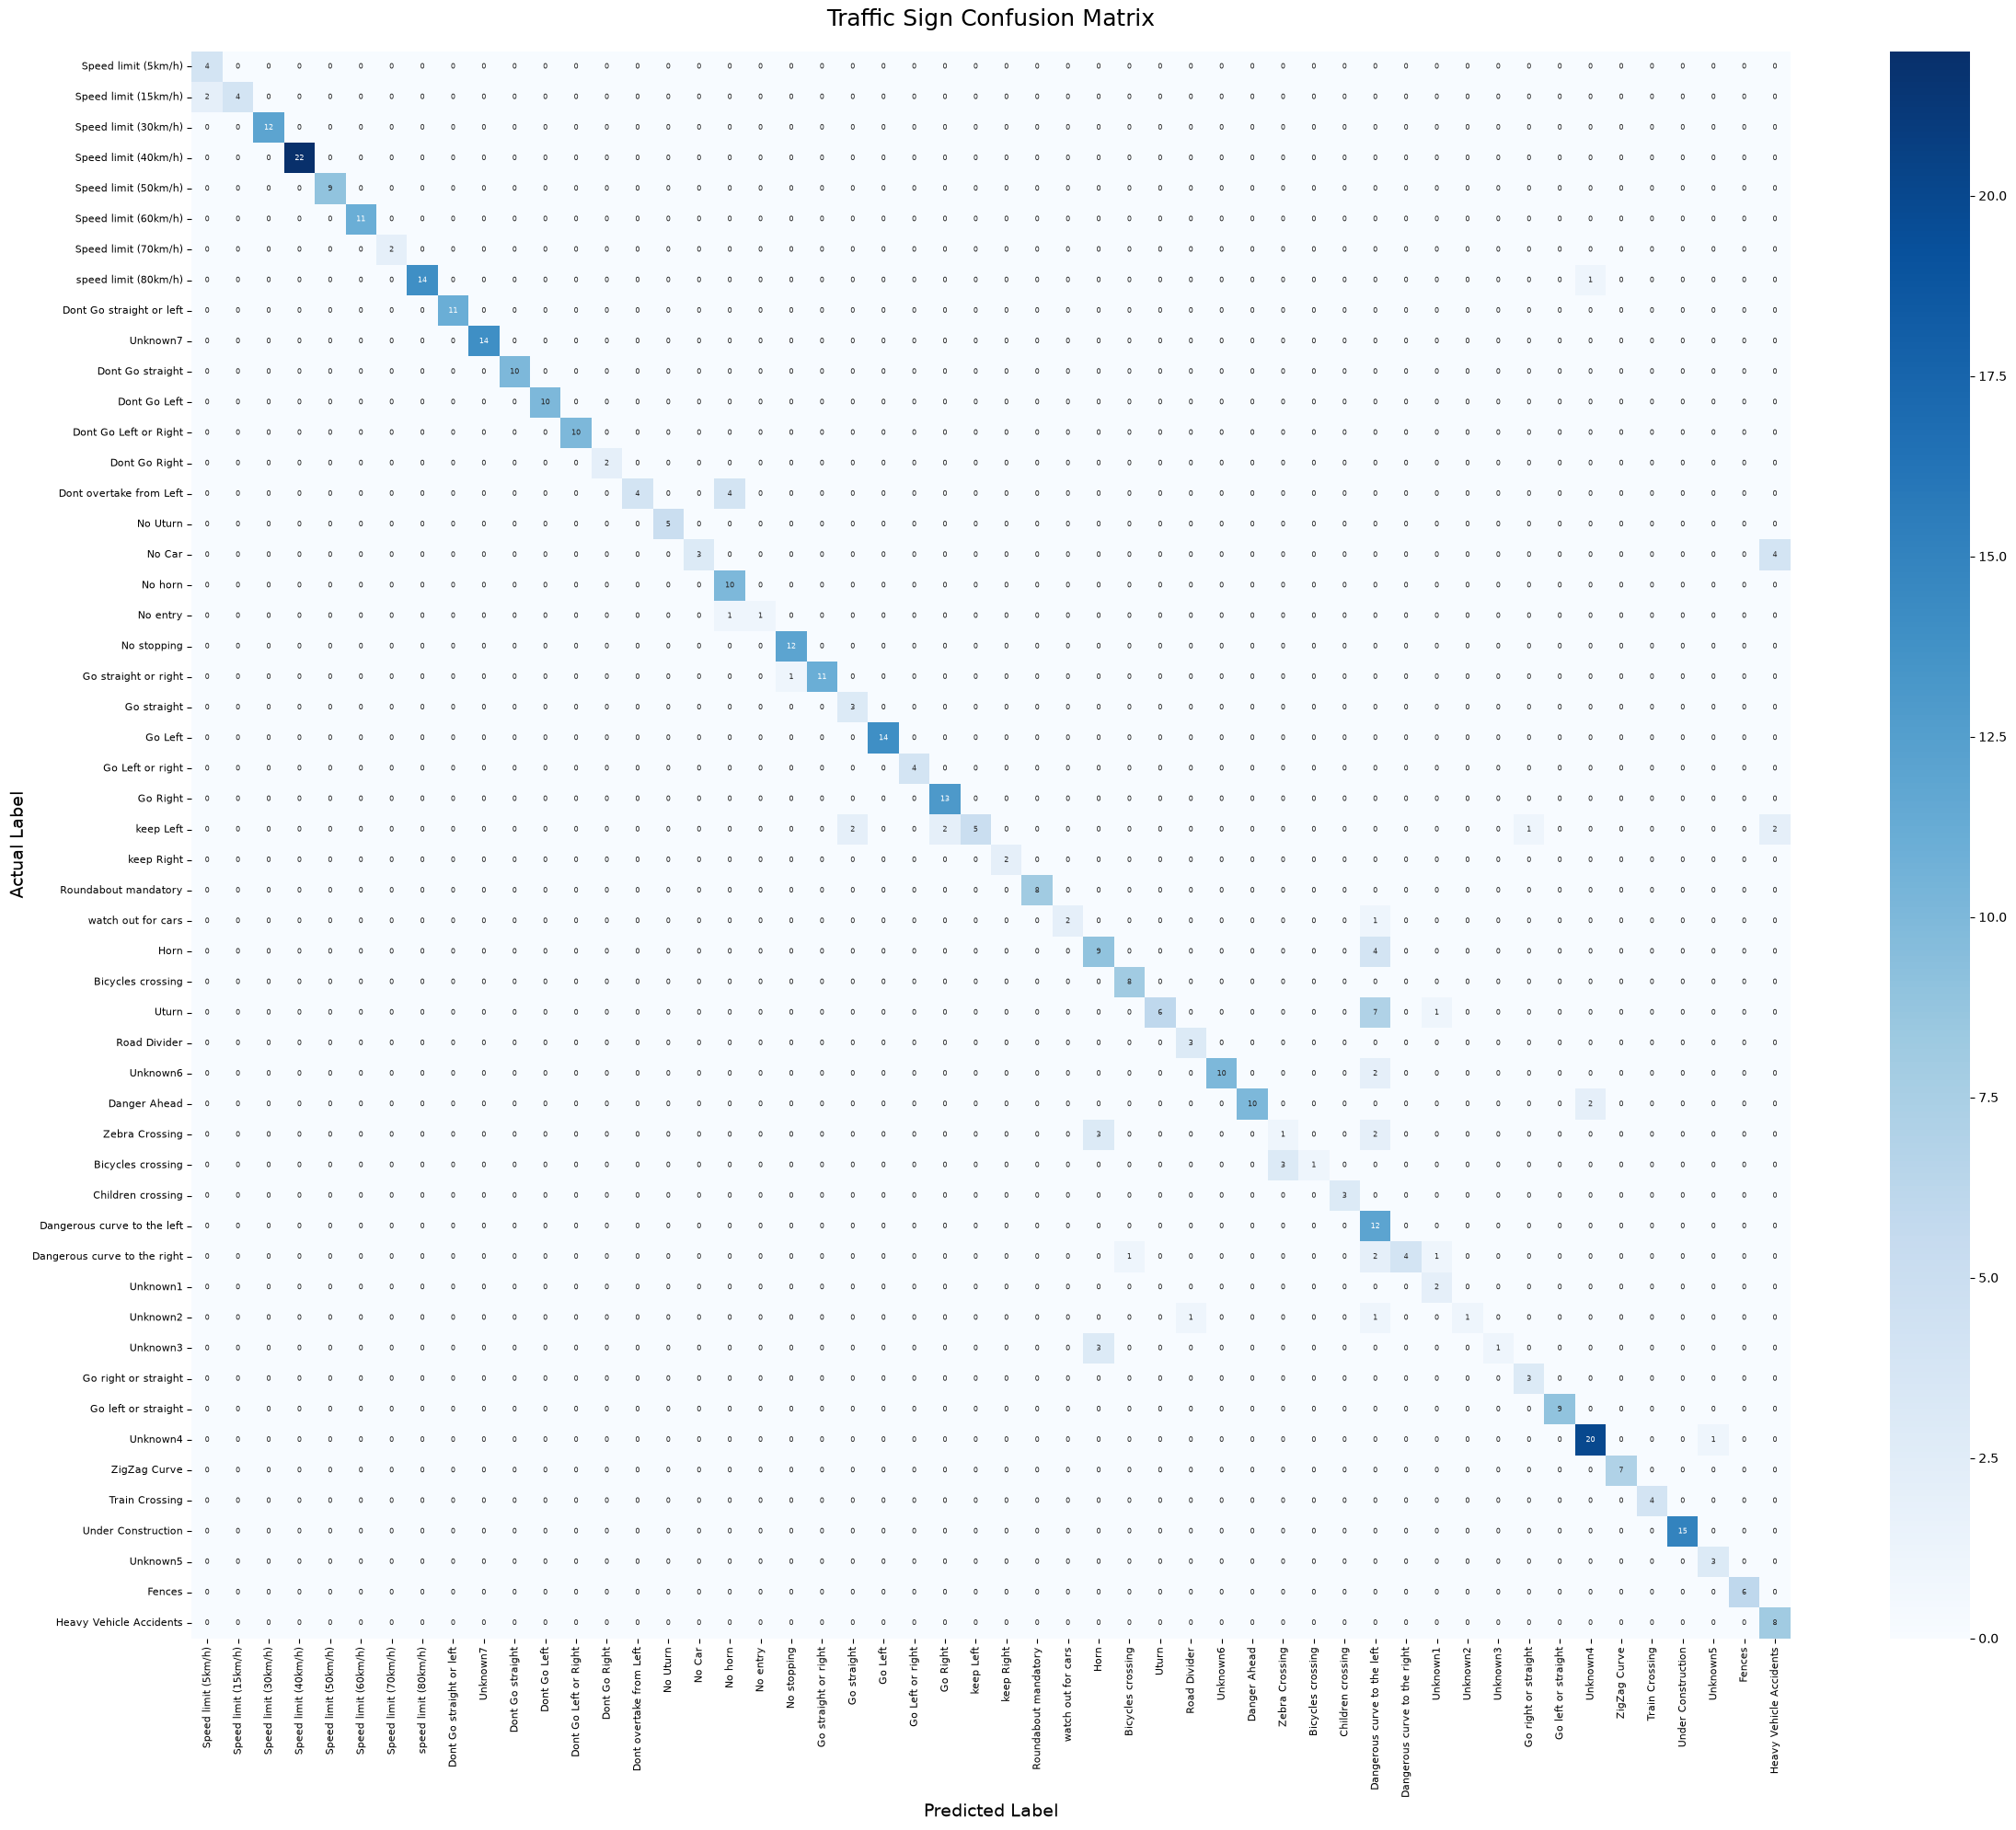

In [8]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 20))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            annot_kws={"size": 6},    
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title('Traffic Sign Confusion Matrix', fontsize=18, pad=20)
plt.ylabel('Actual Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# 4. Improve the label readability
plt.xticks(rotation=90, fontsize=8)    
plt.yticks(fontsize=8)

# 5. Prevent edge clipping
plt.tight_layout()
plt.show()

**Sample prediction**

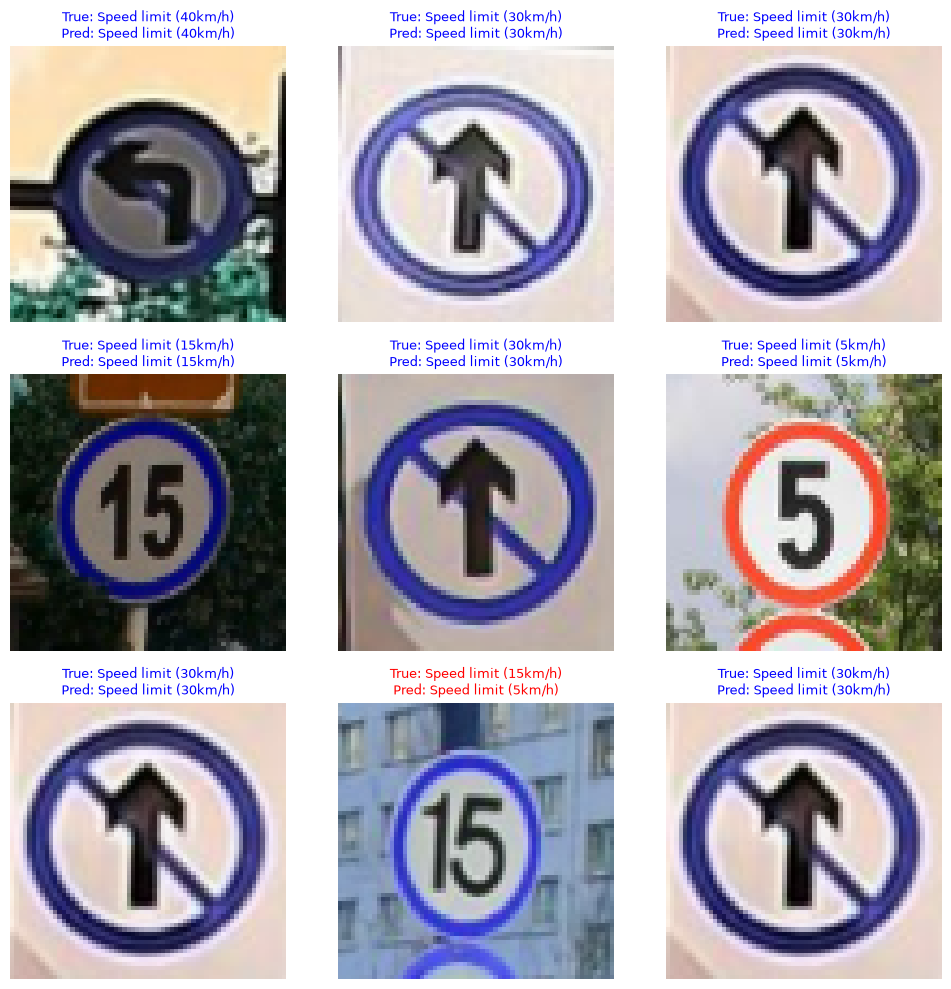

In [14]:
images, labels = next(iter(test_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3 ,3 , i + 1)

    #random images
    idx = random.randint(0, len(images) - 1)
    img = images[idx].numpy().astype("uint8")
    true_label= labels[idx].numpy()

    #predicy one image
    img_expanded = np.expand_dims(images[idx],axis=0)
    pred_prob= model.predict(img_expanded , verbose=0)
    pred_label = np.argmax(pred_prob)

    #text mapping
    true_name = labele_map.get(true_label, "unknown")
    pred_name = labele_map.get(pred_label, "unknow")
    color = 'blue' if true_label == pred_label else "red"

    plt.imshow(img)
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()    




